In [18]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
from matplotlib.cm import get_cmap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
from matplotlib.patches import Rectangle
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.cm as cm
%matplotlib inline

In [2]:
# Define the path

geopath = "/data/rong4/yzhuang/Data/ERA5_1deg/geopotential"

geofiles = [os.path.join(geopath, file) for file in os.listdir(geopath)]

geofilt = []

for f in geofiles:
    
    name = os.path.basename(f)
    
    ym = name.split('.')[2]  # Extract year-month part from filename
    
    yr = int(ym[0:4])
    
    m = int(ym[4:6])

    if 5 <= m <= 9 and 2001 <= yr <= 2018:
        
        geofilt.append(f)

z500 = xr.open_mfdataset(sorted(geofilt), combine='by_coords',  parallel=True)

z500 = z500.sel(latitude=slice(50, 25), longitude=slice(235, 295))

z500['time'] = z500['time'] - pd.Timedelta(hours=6)

_0lst_z500 = z500.sel(time=z500.time.dt.hour == 12)

z = _0lst_z500['z'].load().data

z.shape

(2754, 26, 61)

In [3]:
# reading in ERA5 u, v, w and q

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

years = [str(year) for year in range(2001, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component

u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

w_files = get_files('vertical_velocity', 'vertical_velocity')

all_files = u_files + v_files + w_files

# open all datasets at once

uvw = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

uvw['time'] = uvw['time'] - pd.Timedelta(hours=6)

winds = uvw.sel(level=uvw.level.isin([850, 900]))

winds = winds.where(
    
    (winds.time.dt.month.isin([5, 6, 7, 8, 9])) &
    
    (winds.time.dt.year.isin(range(2001, 2019))),
    
    drop=True
)

In [4]:
winds_900 = winds.sel(level=900)

winds_850 = winds.sel(level=850)

_0lst_900 = winds_900.sel(time=winds_900.time.dt.hour == 0)

u = _0lst_900['u'].load().data

v = _0lst_900['v'].load().data

In [5]:
# removes underground values, contains advections and mean wind profiles

with open('/home/annierosen16/master.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [6]:
dryapes = master[master['dryape']==True][['date', 'latitude', 'longitude']]

wetapes = master[master['wetape']==True][['date', 'latitude', 'longitude']]

/tmp/ipykernel_61006/1365973717.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbar


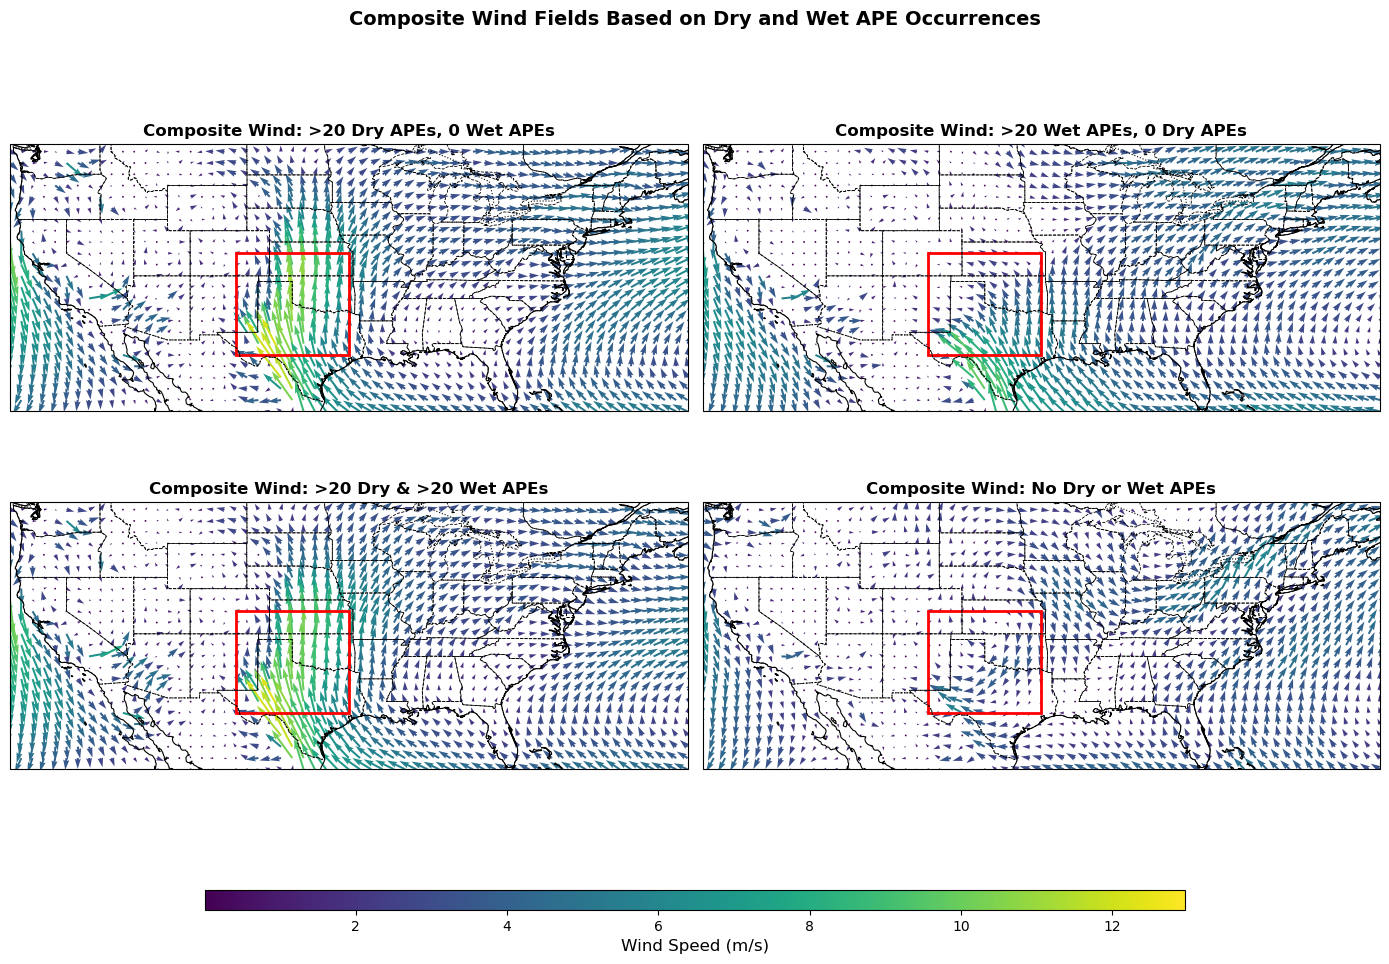

In [7]:
# Step 1: Classify days into four categories

category_1_days, category_2_days, category_3_days, category_4_days = [], [], [], []

for date in pd.to_datetime(_0lst_900['time'].values):
    
    dry_count = len(dryapes[dryapes["date"] == date])
    
    wet_count = len(wetapes[wetapes["date"] == date])

    if dry_count > 20 and wet_count == 0:
        
        category_1_days.append(date)
    
    elif wet_count > 20 and dry_count == 0:
        
        category_2_days.append(date)
    
    elif dry_count > 20 and wet_count > 20:
        
        category_3_days.append(date)
    
    elif dry_count == 0 and wet_count == 0:
        
        category_4_days.append(date)

def compute_composite_wind(dates, time_values, u_array, v_array):
    
    dates = np.array(pd.to_datetime(dates), dtype='datetime64[ns]')
    
    time_values = np.array(time_values, dtype='datetime64[ns]')
    
    # Find matching indices
    
    indices = np.where(np.isin(time_values, dates))[0]

    if len(indices) == 0:
        
        print("Warning: No matching dates found for composite wind calculation.")
        
        return np.full_like(u_array[0], np.nan), np.full_like(v_array[0], np.nan)  # Return NaN arrays

    # Compute mean composite over selected indices
    
    u_composite = np.nanmean(u_array[indices, :, :], axis=0)
    
    v_composite = np.nanmean(v_array[indices, :, :], axis=0)
    
    return u_composite, v_composite

time_values = _0lst_900['time'].values

# Compute composite wind fields using preloaded arrays
u_comp_1, v_comp_1 = compute_composite_wind(category_1_days, time_values, u, v)

u_comp_2, v_comp_2 = compute_composite_wind(category_2_days, time_values, u, v)

u_comp_3, v_comp_3 = compute_composite_wind(category_3_days, time_values, u, v)

u_comp_4, v_comp_4 = compute_composite_wind(category_4_days, time_values, u, v)

wind_speeds = [
    
    np.sqrt(u_comp_1**2 + v_comp_1**2),
    
    np.sqrt(u_comp_2**2 + v_comp_2**2),
    
    np.sqrt(u_comp_3**2 + v_comp_3**2),
    
    np.sqrt(u_comp_4**2 + v_comp_4**2)
]

# Determine global min/max wind speed for consistent colorbar
vmin, vmax = np.nanmin(wind_speeds), np.nanmax(wind_speeds)

norm = Normalize(vmin=vmin, vmax=vmax)

cmap = cm.viridis  # Choose colormap (viridis, plasma, jet, etc.)

# Step 3: Prepare for plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

titles = [
    "Composite Wind: >20 Dry APEs, 0 Wet APEs",
    "Composite Wind: >20 Wet APEs, 0 Dry APEs",
    "Composite Wind: >20 Dry & >20 Wet APEs",
    "Composite Wind: No Dry or Wet APEs"
]

composites = [(u_comp_1, v_comp_1), (u_comp_2, v_comp_2), (u_comp_3, v_comp_3), (u_comp_4, v_comp_4)]

wind_magnitudes = wind_speeds  # Wind speed arrays for color mapping

lons = _0lst_900['longitude'].values

lats = _0lst_900['latitude'].values

lon_grid, lat_grid = np.meshgrid(lons, lats)

lon_min, lon_max = np.min(lons), np.max(lons)

lat_min, lat_max = np.min(lats), np.max(lats)

# Subsampling every 4th grid point
quiver_step = 4

# Step 4: Plot the composite wind fields
for ax, (u_comp, v_comp), wind_speed, title in zip(axes.flatten(), composites, wind_magnitudes, titles):
    
    ax.set_extent([lon_min, lon_max, lat_min, lat_max-5])

    # Subsample grid points for plotting
    u_sub = u_comp[::quiver_step, ::quiver_step]
    
    v_sub = v_comp[::quiver_step, ::quiver_step]
    
    wind_speed_sub = wind_speed[::quiver_step, ::quiver_step]
    
    lon_sub = lon_grid[::quiver_step, ::quiver_step]
    
    lat_sub = lat_grid[::quiver_step, ::quiver_step]

    # Plot quiver with color representing wind speed
    quiv = ax.quiver(
        
        lon_sub, lat_sub, u_sub, v_sub, wind_speed_sub,
        
        transform=ccrs.PlateCarree(), scale=200, width=0.003,
        
        cmap=cmap, norm=norm
    )

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
    
    ax.add_feature(cfeature.STATES, linestyle="--", linewidth=0.6, edgecolor="black")
    
    sgp_lon_min, sgp_lon_max = -105, -95
    sgp_lat_min, sgp_lat_max = 30, 39

    box = Rectangle((sgp_lon_min, sgp_lat_min), sgp_lon_max - sgp_lon_min, sgp_lat_max - sgp_lat_min,
                linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree())

    ax.add_patch(box)

    ax.set_title(title, fontsize=12, fontweight="bold")

# Add a single colorbar for all subplots
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.02])  # Adjust position as needed

cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')

cbar.set_label("Wind Speed (m/s)", fontsize=12)

plt.suptitle("Composite Wind Fields Based on Dry and Wet APE Occurrences", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbar

plt.show()

/tmp/ipykernel_61006/1323985466.py:59: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("turbo")
/tmp/ipykernel_61006/1323985466.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbar


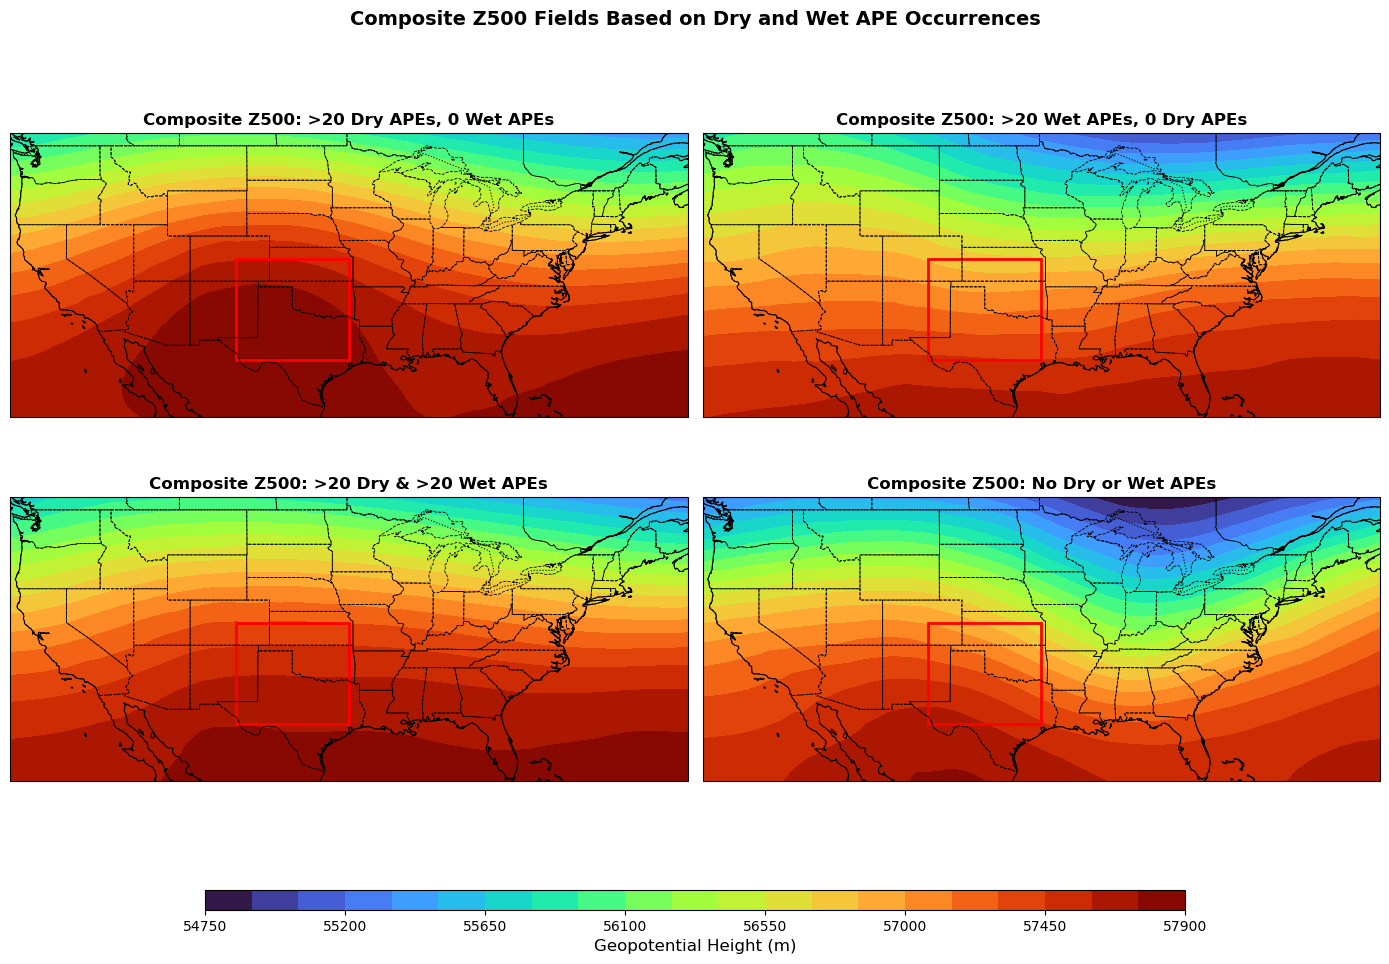

In [56]:
# Define map bounds

sgp_lon_min, sgp_lon_max = -105, -95

sgp_lat_min, sgp_lat_max = 30, 39

# Compute composite means for each category

# Convert the time coordinate to just dates (drop hours, minutes, etc.)
z500_dates = np.array([pd.Timestamp(t).date() for t in _0lst_z500.time.values])

# Convert category_*_days lists to sets of dates for fast lookup

category_1_dates = set(pd.Timestamp(d).date() for d in category_1_days)

category_2_dates = set(pd.Timestamp(d).date() for d in category_2_days)

category_3_dates = set(pd.Timestamp(d).date() for d in category_3_days)

category_4_dates = set(pd.Timestamp(d).date() for d in category_4_days)

# Find indices where the dates match

category_1_indices = np.array([i for i, d in enumerate(z500_dates) if d in category_1_dates])

category_2_indices = np.array([i for i, d in enumerate(z500_dates) if d in category_2_dates])

category_3_indices = np.array([i for i, d in enumerate(z500_dates) if d in category_3_dates])

category_4_indices = np.array([i for i, d in enumerate(z500_dates) if d in category_4_dates])

# Select data using isel (since we now have integer indices)
z500_composites = [
    
    _0lst_z500.isel(time=category_1_indices).mean(dim="time"),
    
    _0lst_z500.isel(time=category_2_indices).mean(dim="time"),
    
    _0lst_z500.isel(time=category_3_indices).mean(dim="time"),
    
    _0lst_z500.isel(time=category_4_indices).mean(dim="time"),
]

# Extract z500 values
z500_values = [comp["z"] for comp in z500_composites]

# Get latitude and longitude grid
lons = _0lst_z500['longitude'].values

lats = _0lst_z500['latitude'].values

lon_grid, lat_grid = np.meshgrid(lons, lats)

# Determine global min/max z500 values for consistent contour levels
vmin, vmax = np.nanmin(z500_values), np.nanmax(z500_values)

norm = Normalize(vmin=vmin, vmax=vmax)

cmap = get_cmap("turbo")

# Set up figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

titles = [
    "Composite Z500: >20 Dry APEs, 0 Wet APEs",
    "Composite Z500: >20 Wet APEs, 0 Dry APEs",
    "Composite Z500: >20 Dry & >20 Wet APEs",
    "Composite Z500: No Dry or Wet APEs"
]

# Plot contours for each category
for ax, z500, title in zip(axes.flatten(), z500_values, titles):
    
    ax.set_extent([np.min(lons), np.max(lons), np.min(lats), np.max(lats)-3.5])

    # Plot filled contours
    contour = ax.contourf(lon_grid, lat_grid, z500, levels=20, cmap=cmap, norm=norm, transform=ccrs.PlateCarree())

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)
    
    ax.add_feature(cfeature.STATES, linestyle="--", linewidth=0.6, edgecolor="black")

    # Add bounding box
    box = Rectangle((sgp_lon_min, sgp_lat_min), sgp_lon_max - sgp_lon_min, sgp_lat_max - sgp_lat_min,
                    linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree())
    
    ax.add_patch(box)

    ax.set_title(title, fontsize=12, fontweight="bold")

# Add a single colorbar
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.02])  # Adjust position as needed

cbar = plt.colorbar(contour, cax=cbar_ax, orientation='horizontal')

cbar.set_label("Geopotential Height (m)", fontsize=12)

# Set figure title
plt.suptitle("Composite Z500 Fields Based on Dry and Wet APE Occurrences", fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space for colorbar

plt.show()


In [49]:
matching_dates = [d for d in z500_dates if d in category_1_dates]
len(matching_dates)

455